# What does a CAI value actually mean?

The Codon Adaptation Index (CAI) is routinely used to judge how well a coding
sequence is adapted to its host. It is a single number between 0 and 1, easy to
compare: which is precisely what makes it easy to misread.

Running the same sequences through two implementations gives different values.
This notebook asks where that difference comes from, and whether a CAI can be
interpreted on its own.

Three questions are addressed:

1. Does the **definition** matter? The original formulation excludes stop codons
   and single-codon amino acids. Including them changes the arithmetic, but by
   how much?
2. Does the **reference table** matter? A CAI is always computed against a set
   of reference genes. Different sets give different weights.
3. Are the parameters used to optimise a sequence **separable**? Codon choice
   moves CAI, GC content and secondary structure at the same time, which makes
   any threshold on one of them hard to interpret.

All calculations use `cai.py`, a transparent implementation where every
methodological choice is an explicit argument.

## Setup

The reference table is the human codon usage table from the Kazusa database
(species 9606, standard genetic code, downloaded 2026-09-08). It is built on
93_487 coding sequences, which makes it a picture of the *average* usage
across the transcriptome, not of the usage of highly expressed genes.

This distinction matters and comes back in the second section.

In [1]:
import collections
import random

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr

import cai

In [2]:
codon_table = cai.read_kazusa_table("kazusa.txt")
weight_table = cai.create_weight_table(codon_table)
synonym_table = cai.create_synonym_table(codon_table)

## Reading the reference table

The weight of a codon is its usage divided by the usage of the most frequent
codon of the same amino acid. The preferred codon of every family therefore has
a weight of 1, and the others fall between 0 and 1.

Families differ widely in how skewed they are: some amino acids have a clearly
dominant codon, others spread their usage evenly. The more skewed a family, the
more a bad choice costs.

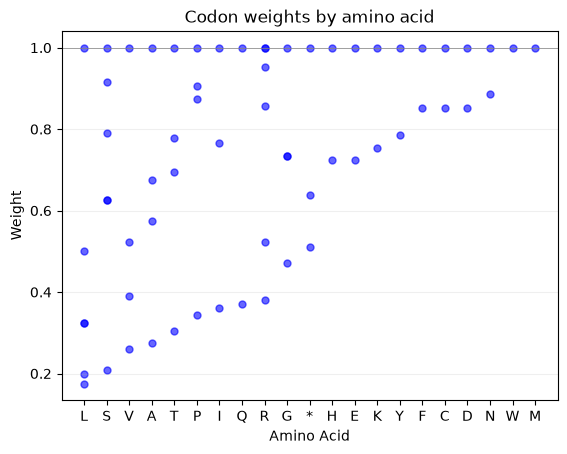

In [3]:
families = collections.defaultdict(list)
for amino_acid, weight, _ in weight_table.values():
    families[amino_acid].append(weight)

minimums = {amino_acid: min(weights)
            for amino_acid, weights in families.items()}
order = sorted(minimums, key=minimums.get)

aas = []
weights = []
for amino_acid in order:
    for weight in families[amino_acid]:
        aas.append(amino_acid)
        weights.append(weight)

fig, ax = plt.subplots()
ax.scatter(aas, weights, marker="o", color="blue", s=25, alpha=0.6)
ax.set_xlabel("Amino Acid")
ax.set_ylabel("Weight")
ax.set_title("Codon weights by amino acid")
ax.grid(axis="y", alpha=0.2)
ax.axhline(1, color="grey", linewidth=0.5)

Amino acid frequencies are computed from the human reference proteome
(UniProt UP000005640, reviewed entries only, canonical sequences, downloaded
2026-09-10), which contains 147_520 protein sequences. The file is not included in
this repository because of its size; the exact query is
`(proteome:up000005640) AND (reviewed:true)` on
[UniProt](https://www.uniprot.org/uniprotkb). The outputs below are kept in the
notebook so the results can be read without re-running the calculation.

Selenocysteine (U) and undetermined residues (X) appear in a handful of entries
and are dropped before ranking, since neither has a dedicated codon.

In [4]:
proteome = cai.read_fasta("human-proteome.fasta")
residue_counts = collections.Counter("".join(proteome.values()))

ranked_residues = enumerate(residue_counts.most_common(), start=1)
ranks = {residue: rank for rank, (residue, _) in ranked_residues
         if residue not in "UX"}

total = sum(residue_counts.values())
print(f"{len(proteome)} sequences, {total} residues")
print(f"L + S: {(residue_counts['L'] + residue_counts['S']) / total:.1%}")
residue_counts.most_common(5)

147520 sequences, 69583259 residues
L + S: 18.1%


[('L', 6927426),
 ('S', 5690927),
 ('E', 5082947),
 ('A', 4960002),
 ('G', 4567759)]

In [5]:
weights_df = pd.DataFrame({
    "min_weight": [minimums[aa] for aa in order],
    "nb_synonyms": [len(families[aa]) for aa in order],
    "abundance_rank": [ranks.get(aa) for aa in order],
}, index=order)

weights_df.round(3)

,min_weight,nb_synonyms,abundance_rank
L,0.175,6,1.0
S,0.208,6,2.0
V,0.261,4,7.0
A,0.275,4,4.0
T,0.306,4,10.0
P,0.344,4,6.0
I,0.362,3,13.0
Q,0.370,2,12.0
R,0.381,6,9.0
G,0.471,4,5.0


Families differ far more than the genetic code alone would suggest. The number
of synonymous codons sets a rough upper bound on how skewed a family can be, but
it predicts the actual skew poorly: glutamine has two codons and a minimum weight
of 0.37, where every other two-codon family stays above 0.72; isoleucine has
three codons for a minimum of 0.36; arginine has six, yet sits mid-table at 0.38,
far from leucine and serine at the same family size. What the weights reflect is
tRNA availability, not arithmetic.

Two patterns of skew show up in the figure, with different practical
consequences. In proline and threonine a single codon drops below 0.4 while the
others cluster above 0.6: one codon to avoid, and the choice is made. In leucine,
valine and serine the skew is spread out: five of the six leucine codons fall
below 0.5. There, most options are poor and the codon has to be picked
deliberately.

This matters because families do not contribute equally. On phenylalanine,
cysteine, aspartate and asparagine the worst codon still weighs above 0.85, so the
choice barely moves the index. On leucine a poor codon weighs 0.175, and in a
geometric mean a single low weight pulls down much harder than a high one
compensates.

The abundance ranking makes the point concrete. Leucine and serine, the two most
skewed families, are also the two most frequent residues in the human proteome:
together they account for 18.1% of all residues. Much of the CAI of a sequence
is therefore decided on these positions.

## Does the definition matter?

Sharp & Li exclude methionine, tryptophan and stop codons from the calculation,
for two different reasons.

Met and Trp have a single codon each, so their weight is fixed at 1 and carries
no information about codon choice. Including them only adds ones to the
geometric mean.

Stop codons are excluded on other grounds: they encode no amino acid, and their
usage is under constraints of its own. They do have synonyms and therefore
weights below 1, so including them can push the index either way.

The question is whether any of this changes anything in practice.

### The test sequences

All six sequences encode the same protein, firefly luciferase, and differ only in
codon choice. They come from four independent optimisers:

- **tool_A**, **tool_B** and **tool_C** are commercial codon optimisation
  services, each applying its own undisclosed criteria.
- **LDesign_85**, **LDesign_90** and **LDesign_95** were produced with
  [LinearDesign](https://github.com/LinearDesignSoftware/LinearDesign), which
  searches for the sequence with the lowest folding energy under a CAI
  constraint. The three were generated with a target CAI of 0.85, 0.90 and 0.95
  respectively, against the same Kazusa table used here.

The LDesign series is useful twice over: it spans a range of CAI values on an
otherwise identical protein, and its targets provide an external check on the
calculation.

The six sequences are first checked to encode the same protein.

In [6]:
sequences = cai.read_fasta("CDS_sequences.txt")

proteins = [cai.translate(sequence, codon_table)
            for sequence in sequences.values()]
print(f"{len(proteins)} sequences, {len(set(proteins))} distinct protein(s), "
      f"{len(proteins[0])} residues")

6 sequences, 1 distinct protein(s), 551 residues


In [7]:
cds_list = list(sequences.values())
options = {
    "Default": {},
    "+ unique": {"unique": True},
    "+ stop": {"stop": True},
    "+ both": {"stop": True, "unique": True},
}

cai_df = pd.DataFrame(
    {label: [cai.calculate_cai(seq, weight_table, **kwargs)
             for seq in cds_list]
     for label, kwargs in options.items()},
    index=list(sequences),
)
cai_df.round(3)

,Default,+ unique,+ stop,+ both
Luc_tool_A,0.994,0.994,0.993,0.993
Luc_tool_B,0.933,0.935,0.933,0.935
Luc_tool_C,0.925,0.927,0.925,0.927
Luc_LDesign_85,0.855,0.858,0.854,0.858
Luc_LDesign_90,0.913,0.916,0.913,0.915
Luc_LDesign_95,0.952,0.953,0.951,0.952


The four variants differ by at most 0.004 on these sequences, and the two
exclusions pull in opposite directions, as expected:

- including single-codon amino acids adds weights of 1 and raises the index
  slightly;
- including stop codons adds weights below 1 and lowers it.

Both effects are diluted in a geometric mean taken over 550 codons, and
neither is what makes implementations disagree on real sequences.

The LDesign sequences give an independent check on the calculation:
generated against target CAI values of 0.85, 0.90 and 0.95 using the same
Kazusa table loaded here, they score 0.855, 0.913 and 0.952 above. Two
independent implementations working from the same reference table agree to
within a few thousandths.

Whatever explains a larger disagreement, it is neither the definition nor
the implementation.


## Does the reference table matter?

The same six sequences were submitted to [JCat](https://www.jcat.de/), a widely
used codon adaptation server, with *Homo sapiens* as the target organism. Its CAI
values are compared below to the ones computed here.

JCat lets the user pick an organism from a fixed list, but not supply a reference
table. Its reference set is built automatically with the iterative algorithm of
Carbone et al.: starting from all genes of an organism, it narrows down to the 1%
with the strongest codon bias (Grote et al., 2005). The table used in this
notebook covers the whole transcriptome instead. The two references are therefore
built on very different sets of genes, and neither is wrong: they answer
different questions.

In [8]:
# CAI values obtained by pasting each sequence into the JCat web form
# (https://www.jcat.de/), Homo sapiens, retrieved 2026-09-10. No
# programmatic interface was found for this server.
jcat_cai = {
    "Luc_tool_A": 0.9572,
    "Luc_tool_B": 0.5575,
    "Luc_tool_C": 0.5441,
    "Luc_LDesign_85": 0.5647,
    "Luc_LDesign_90": 0.6370,
    "Luc_LDesign_95": 0.7156,
}

comparison = pd.DataFrame({
    "this_notebook": cai_df["Default"],
    "jcat": [jcat_cai[name] for name in cai_df.index],
})
comparison["difference"] = comparison["this_notebook"] - comparison["jcat"]
comparison["rank_here"] = (
    comparison["this_notebook"].rank(ascending=False).astype(int)
)
comparison["rank_jcat"] = (
    comparison["jcat"].rank(ascending=False).astype(int)
)
comparison.round(3)

,this_notebook,jcat,difference,rank_here,rank_jcat
Luc_tool_A,0.994,0.957,0.037,1,1
Luc_tool_B,0.933,0.558,0.375,3,5
Luc_tool_C,0.925,0.544,0.381,4,6
Luc_LDesign_85,0.855,0.565,0.290,6,4
Luc_LDesign_90,0.913,0.637,0.276,5,3
Luc_LDesign_95,0.952,0.716,0.236,2,2


In [9]:
rho, _ = spearmanr(comparison["this_notebook"], comparison["jcat"])
print(f"Spearman rank correlation: {rho:.3f}")

Spearman rank correlation: 0.543


The two sets of values are not comparable. The gap ranges from 0.037 on
Luc_tool_A to 0.381 on Luc_tool_C, and it is the irregularity of that gap
that rules out a difference in definition: a definitional difference would
produce a small, roughly constant offset, as the previous section showed.

More importantly, the ranking is not preserved. Spearman's rank correlation
between the two sets is 0.54: a value of 1 would mean the two references
agree completely on ordering, even if they disagree on scale. On six
sequences, 0.54 means the orderings share little more than their extremes.
Luc_tool_A comes first under both, but Luc_tool_B and Luc_tool_C score above
Luc_LDesign_85 here and fall below it under JCat.

Two consequences follow:

- **A CAI has no meaning without its reference table.** The same six
  sequences score between 0.86 and 0.99 here, and between 0.54 and 0.96
  under JCat. It is on whoever reports a CAI to state the reference it was
  computed against.
- **Ranking is not a safe fallback either.** Any threshold, any selection
  between candidates, has to be made against one reference table, fixed
  once and documented.


## Are the optimisation parameters separable?

Optimising a coding sequence means choosing among synonymous codons, but
every choice moves several properties at once: CAI, GC content, U content,
secondary structure. Raising the CAI of a human sequence pushes towards G
and C in third position: as shown below, 17 of the 18 multi-codon families
have their preferred codon ending in G or C. GC content therefore tends to
rise with the CAI, and GC-rich sequences tend to fold into more stable
secondary structures.

This makes any threshold hard to interpret: a sequence that translates well
at CAI 0.9 may owe its performance to its GC content rather than to its
codon adaptation, and the two cannot be told apart if they always move
together.

A classical design of experiments would fix one factor and vary the other,
but these values cannot be set in advance. The approach taken here is the
reverse: generate a large number of synonymous variants at random, then
look at the shape of the cloud they form.


In [10]:
preferred_gc3 = []
for amino_acid, codons in synonym_table.items():
    if amino_acid == "*" or len(codons) == 1:
        continue
    preferred = max(codons, key=lambda codon: weight_table[codon][1])
    preferred_gc3.append((amino_acid, preferred, preferred[2] in "GC"))

gc3_count = sum(ends_in_gc for _, _, ends_in_gc in preferred_gc3)
print(f"{gc3_count} of {len(preferred_gc3)} multi-codon families have their "
      f"preferred codon ending in G or C")

[(aa, codon) for aa, codon, ends in preferred_gc3 if not ends]

17 of 18 multi-codon families have their preferred codon ending in G or C


[('R', 'AGA')]

Spearman correlation: 0.964


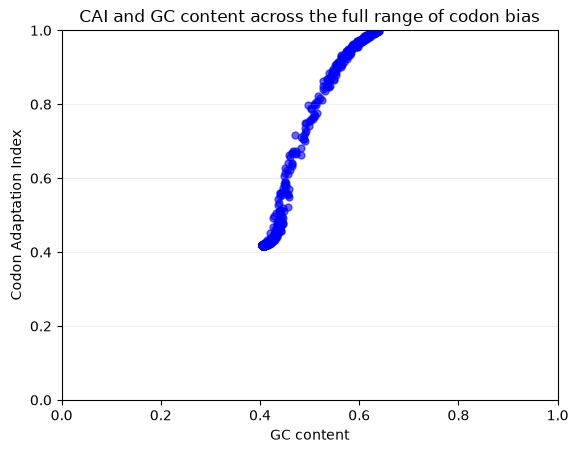

In [11]:
random.seed(2026)

prot_luc = (
    "MEDAKNIKKGPAPFYPLEDGTAGEQLHKAMKRYALVPGTIAFTDAHIEVNITYAEYFEMSVRLAEAMKRY"
    "GLNTNHRIVVCSENSLQFFMPVLGALFIGVAVAPANDIYNERELLNSMNISQPTVVFVSKKGLQKILNVQ"
    "KKLPIIQKIIIMDSKTDYQGFQSMYTFVTSHLPPGFNEYDFVPESFDRDKTIALIMNSSGSTGLPKGVAL"
    "PHRTACVRFSHARDPIFGNQIIPDTAILSVVPFHHGFGMFTTLGYLICGFRVVLMYRFEEELFLRSLQDY"
    "KIQSALLVPTLFSFFAKSTLIDKYDLSNLHEIASGGAPLSKEVGEAVAKRFHLPGIRQGYGLTETTSAIL"
    "ITPEGDDKPGAVGKVVPFFEAKVVDLDTGKTLGVNQRGELCVRGPMIMSGYVNNPEATNALIDKDGWLHS"
    "GDIAYWDEDEHFFIVDRLKSLIKYKGYQVAPAELESILLQHPNIFDAGVAGLPDDDAGELPAAVVVLEHG"
    "KTMTEKEIVDYVASQVTTAKKLRGGVVFVDEVPKGLTGKLDARKIREILIKAKKGGKSKL"
)  # UniProt P08659, firefly luciferase

gc_variants = []
cai_variants = []
bias = -40
while bias < 40:
    for _ in range(10):
        variant = cai.random_variant(prot_luc, synonym_table, weight_table,
                                      bias)
        gc_variants.append(cai.gc_content(variant))
        cai_variants.append(cai.calculate_cai(variant, weight_table))
    bias += 0.5

fig, ax = plt.subplots()
ax.scatter(gc_variants, cai_variants, marker="o", color="blue", s=25,
           alpha=0.6)
ax.set_xlabel("GC content")
ax.set_ylabel("Codon Adaptation Index")
ax.set_title("CAI and GC content across the full range of codon bias")
ax.grid(axis="y", alpha=0.2)
ax.axhline(1, color="grey", linewidth=0.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

rho, _ = spearmanr(gc_variants, cai_variants)
print(f"Spearman correlation: {rho:.3f}")

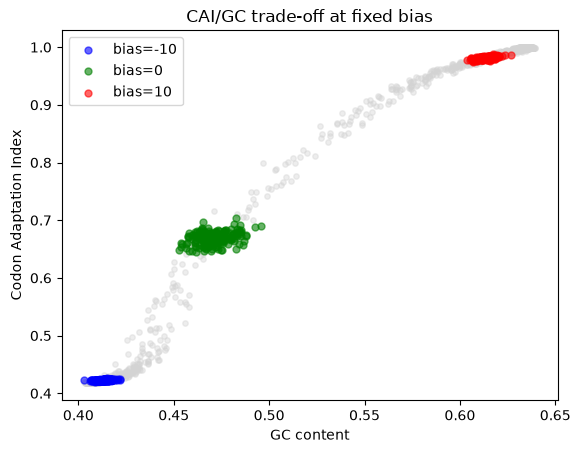

In [12]:
random.seed(2026)

biases = [-10, 0, 10]
results = {bias: {"gc": [], "cai": []} for bias in biases}

for bias in biases:
    for _ in range(200):
        variant = cai.random_variant(prot_luc, synonym_table, weight_table,
                                      bias)
        results[bias]["gc"].append(cai.gc_content(variant))
        results[bias]["cai"].append(cai.calculate_cai(variant, weight_table))

fig, ax = plt.subplots()
ax.scatter(gc_variants, cai_variants, marker="o", color="lightgrey", s=15,
           alpha=0.4)

colors = {-10: "blue", 0: "green", 10: "red"}
for bias in biases:
    ax.scatter(results[bias]["gc"], results[bias]["cai"], color=colors[bias],
               s=25, alpha=0.6, label=f"bias={bias}")
ax.set_xlabel("GC content")
ax.set_ylabel("Codon Adaptation Index")
ax.set_title("CAI/GC trade-off at fixed bias")
ax.legend()

In [13]:
ranges = pd.DataFrame({
    "gc_min": [min(results[b]["gc"]) for b in biases],
    "gc_max": [max(results[b]["gc"]) for b in biases],
    "cai_min": [min(results[b]["cai"]) for b in biases],
    "cai_max": [max(results[b]["cai"]) for b in biases],
}, index=biases)
ranges["gc_range"] = ranges["gc_max"] - ranges["gc_min"]
ranges["cai_range"] = ranges["cai_max"] - ranges["cai_min"]
ranges.round(3)


,gc_min,gc_max,cai_min,cai_max,gc_range,cai_range
-10,0.403,0.422,0.419,0.426,0.019,0.006
0,0.453,0.496,0.645,0.703,0.043,0.058
10,0.604,0.627,0.974,0.988,0.023,0.013


Across the whole range explored, from strongly disfavouring to strongly
favouring the preferred codon, CAI and GC content trace a single curve. The
Spearman correlation between the two is 0.964: no bias produces a high CAI
at low GC, or the reverse. At the scale of the full curve, the two
parameters move together.

Looking within a fixed bias tells a more precise story. At bias 0, 200
variants span a GC range of 0.043 and a CAI range of 0.058. Moving to the
extremes narrows both ranges, but unevenly: at bias -10 the CAI range drops
to 0.006, about a tenth of its value at the centre, while the GC range only
drops to 0.019, under half. At bias 10 the pattern repeats: CAI range 0.013,
about a fifth of the centre value, against GC range 0.023, again about half.
Dispersion in CAI collapses much faster than dispersion in GC as the bias
moves away from the centre. 
That local margin is modest, though. The full curve spans roughly 25 points
of GC content; a 4 point margin at fixed bias is about a sixth of that.
Whether it is useful in practice depends on how large a GC difference
actually matters for a given design goal.

Whether this room is useful depends on where translation actually requires
the CAI to sit. The margin observed here appears around CAI 0.65 to 0.70. If
adequate expression only requires a value in that range, the flexibility is
exploitable. If it requires something closer to 0.85 or 0.90, this margin
sits below the useful range, and any trade-off would have to be examined
near the top of the curve instead, where the observed range was much
narrower.

And that threshold is itself reference-dependent. A CAI target only means
something against the table it was computed with, as the previous section
showed. A value of 0.85 against the whole-transcriptome table used here is
not the same target as 0.85 against a highly-expressed-gene table. Any
translation threshold established in the literature has to be read together
with the reference it was measured against, or reproduced against the
reference actually used here before it can be applied.


## Conclusion

A CAI value is easy to compute and easy to compare, which is precisely why
it is easy to misread. Four things came out of testing it against real
sequences and against another tool.

Amino acid families are not equally sensitive to codon choice. Leucine and
serine carry six codons each, and the weight of their worst codon falls
below 0.21 in both. Together they occupy 18% of the residues in a typical
human protein, each an independent choice with a wide range of outcomes. A
sequence's CAI is decided mostly at these positions, not because the same
codon repeats, but because so many positions carry this much weight.

The formula itself is not where implementations disagree. Including or
excluding stop codons and single-codon amino acids shifted the index by at
most 0.004 on full-length sequences, and the calculation matched an
independent tool, LinearDesign, to within a few thousandths when both used
the same reference table.

The reference table is where they disagree. The same six sequences scored
between 0.86 and 0.99 here and between 0.54 and 0.96 under JCat, and the two
tools did not even rank the sequences the same way. A CAI value only means
something alongside the reference table it was computed against. It is on
whoever reports the value to state that reference; without it, comparing
CAI values computed by different tools or from different papers answers
nothing.

Codon optimisation cannot be reduced to raising the CAI in isolation,
because CAI and GC content move together. Across the full range of codon
bias tested, they trace a single curve with no independent variation. Some
room to trade one against the other does appear locally, at moderate bias,
but it narrows sharply toward the extremes. Whether that room is of any
practical use depends on the CAI level actually required for efficient
translation, a threshold this notebook does not establish, and which is
itself only meaningful against a stated reference table.

None of this makes the CAI useless. It makes it a comparative tool: useful
for ranking variants scored against the same table, not for reading a
single value in isolation or comparing it across sources that do not share
a reference.

## Limitations

- No consensus reference table exists for highly expressed human genes; the
  choice of the whole-transcriptome Kazusa table is documented here, not
  justified as optimal.
- Kazusa fractions are rounded to two decimals, which introduces a small
  error in the weights of large families; recomputing them from the raw
  counts would remove it.
- The stop codon was fixed across all six test sequences, but is drawn at
  random when generating synonymous variants; this has no measurable effect
  at this scale.
- Variants were generated by biased random sampling at the level of
  individual codons. This is not how a real optimiser searches the sequence
  space, and it does not guarantee that the CAI/GC trade-off observed here
  is the best achievable one.
- Secondary structure (MFE) was not computed. LinearDesign optimises it
  jointly with the CAI constraint, and it may interact with the CAI/GC
  relationship observed here in ways this notebook does not examine.
- Six sequences is a small sample for a rank correlation; the Spearman
  coefficient reported should be read as indicative rather than precise.

## References

Sharp, P.M. & Li, W.-H. (1987) The codon adaptation index, a measure of
directional synonymous codon usage bias, and its potential applications.
Nucleic Acids Research 15(3):1281-1295.

Zhang, H., Zhang, L., Lin, A., Xu, C., Li, Z., Liu, K., Liu, B., Ma, X.,
Zhao, F., Jiang, H., Chen, C., Shen, H., Li, H., Mathews, D.H., Zhang, Y. &
Huang, L. (2023) Algorithm for optimized mRNA design improves stability and
immunogenicity. Nature 621:396-403.
